Importing libraries

In [32]:
import random
random.seed(0)
import json
import os
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mping
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import glob
from tensorflow.keras.layers import Rescaling

from tensorflow.keras.layers import Conv2D,MaxPooling2D,GlobalAveragePooling2D,Dense,Dropout,BatchNormalization,Flatten

#unzipping the zip files of train,validation and test data

In [ ]:
!unzip /content/train-20251204T081958Z-1-001.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/without_mask/without_mask_1536.jpg  
  inflating: train/without_mask/without_mask_590.jpg  
  inflating: train/without_mask/without_mask_3381.jpg  
  inflating: train/without_mask/without_mask_1619.jpg  
  inflating: train/with_mask/with_mask_38.jpg  
  inflating: train/without_mask/without_mask_1748.jpg  
  inflating: train/with_mask/with_mask_217.jpg  
  inflating: train/with_mask/with_mask_1838.jpg  
  inflating: train/with_mask/with_mask_775.jpg  
  inflating: train/without_mask/without_mask_1792.jpg  
  inflating: train/without_mask/without_mask_357.jpg  
  inflating: train/with_mask/with_mask_978.jpg  
  inflating: train/without_mask/without_mask_1098.jpg  
  inflating: train/without_mask/without_mask_2292.jpg  
  inflating: train/without_mask/without_mask_2344.jpg  
  inflating: train/with_mask/with_mask_3656.jpg  
  inflating: train/without_mask/without_mask_2384.jpg  
  inflating: train/with_mask/with_mask_1

In [ ]:
!unzip /content/val-20251204T081726Z-1-001.zip


Archive:  /content/val-20251204T081726Z-1-001.zip
  inflating: val/with_mask/with_mask_1718.jpg  
  inflating: val/with_mask/with_mask_583.jpg  
  inflating: val/without_mask/without_mask_2504.jpg  
  inflating: val/with_mask/with_mask_606.jpg  
  inflating: val/with_mask/with_mask_1736.jpg  
  inflating: val/with_mask/with_mask_3664.jpg  
  inflating: val/with_mask/with_mask_3077.jpg  
  inflating: val/with_mask/with_mask_1524.jpg  
  inflating: val/with_mask/with_mask_1563.jpg  
  inflating: val/with_mask/with_mask_2996.jpg  
  inflating: val/with_mask/with_mask_1824.jpg  
  inflating: val/with_mask/with_mask_2552.jpg  
  inflating: val/with_mask/with_mask_433.jpg  
  inflating: val/with_mask/with_mask_3407.jpg  
  inflating: val/with_mask/with_mask_1797.jpg  
  inflating: val/with_mask/with_mask_3003.jpg  
  inflating: val/with_mask/with_mask_327.jpg  
  inflating: val/with_mask/with_mask_2387.jpg  
  inflating: val/with_mask/with_mask_1943.jpg  
  inflating: val/with_mask/with_mask

In [ ]:
!unzip /content/test-20251204T081729Z-1-001.zip

Archive:  /content/test-20251204T081729Z-1-001.zip
  inflating: test/without_mask/without_mask_1665.jpg  
  inflating: test/without_mask/without_mask_2147.jpg  
  inflating: test/without_mask/without_mask_2475.jpg  
  inflating: test/without_mask/without_mask_2228.jpg  
  inflating: test/without_mask/without_mask_1297.jpg  
  inflating: test/without_mask/without_mask_733.jpg  
  inflating: test/without_mask/without_mask_2871.jpg  
  inflating: test/with_mask/with_mask_455.jpg  
  inflating: test/without_mask/without_mask_2980.jpg  
  inflating: test/without_mask/without_mask_1176.jpg  
  inflating: test/without_mask/without_mask_2547.jpg  
  inflating: test/with_mask/with_mask_2590.jpg  
  inflating: test/without_mask/without_mask_384.jpg  
  inflating: test/without_mask/without_mask_2922.jpg  
  inflating: test/with_mask/with_mask_1174.jpg  
  inflating: test/without_mask/without_mask_2362.jpg  
  inflating: test/with_mask/with_mask_3655.jpg  
  inflating: test/with_mask/with_mask_121

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory("train/",shuffle=True,seed=123,
                                                       image_size=(128,128),
                                                       batch_size=128)

Found 5287 files belonging to 2 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory("val/",shuffle = True,seed = 123,
                                                     image_size=(128,128),
                                                     batch_size=128)

Found 1510 files belonging to 2 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory("test/",shuffle=True,
                                                      seed=123,
                                                      image_size=(128,128),
                                                      batch_size=128)

Found 757 files belonging to 2 classes.


#Data Preprocessing

In [ ]:
data_preprocess = Sequential(
    [
        Rescaling(1.0/225)
    ]
)

In [ ]:

train_ds = train_ds.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_ds.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_ds.map(lambda x, y: (data_preprocess(x), y))

In [ ]:
class_dirs = os.listdir("train/")
class_dirs

['without_mask', 'with_mask']

In [ ]:
class_dirs = os.listdir("train/")
image_dict = {} # dict to store image array(key) for every class(value)
count_dict = {} # dict to store count of files(key) for every class(value)

for cls in class_dirs:
    file_paths = glob.glob(f'train/{cls}/*')
    count_dict[cls] = len(file_paths)
    image_path = random.choice(file_paths)
    image_dict[cls] = tf.keras.utils.load_img(image_path)

In [ ]:
image_dict

{'without_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=263x347>,
 'with_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=194x259>}

In [ ]:
count_dict

{'without_mask': 2679, 'with_mask': 2607}

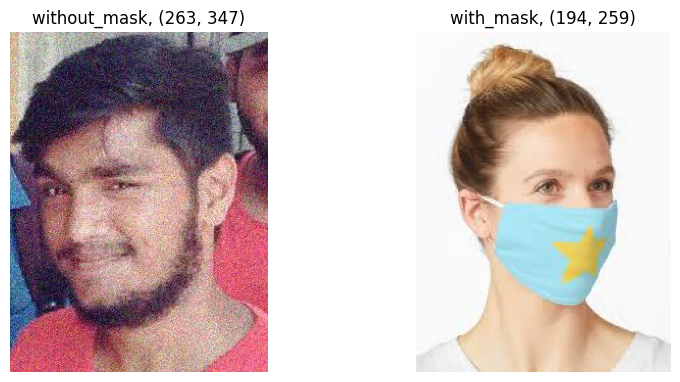

In [ ]:
plt.figure(figsize=(20, 15))

for i, (cls,img) in enumerate(image_dict.items()):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f'{cls}, {img.size}')
    plt.axis("off")

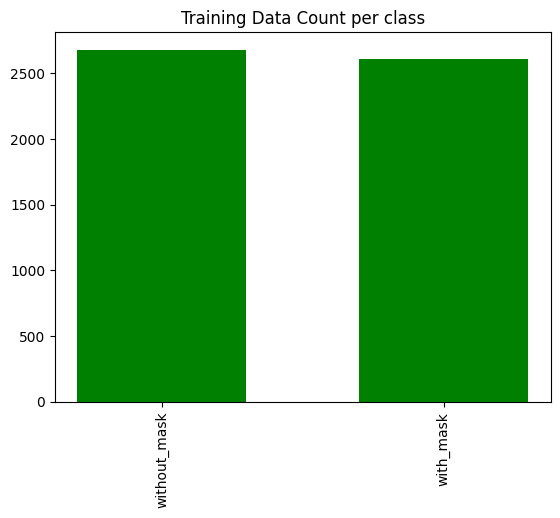

In [ ]:
plt.bar(x=count_dict.keys(), height=count_dict.values(), color='green', width=0.6)
plt.xticks(rotation=90)
plt.title("Training Data Count per class")
plt.show()

In [ ]:
model = Sequential([

    Conv2D(filters = 32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,128, 3)),
    Conv2D(filters = 32, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(filters = 64, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters = 64, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

     Conv2D(filters = 128, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters = 128, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),


    Conv2D(128, kernel_size=(3,3), activation='relu'),
    Conv2D(128, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),


    Dense(1, activation='sigmoid')

])

In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 583,713 (2.23 MB)

 Trainable params: 583,009 (2.22 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss',patience=5,restore_best_weights=True)

In [ ]:
model.compile(
                    optimizer = 'adam',
                    loss = 'binary_crossentropy',
                    metrics = ['accuracy']
                   )

In [ ]:
history = model.fit(train_ds, epochs=20, validation_data=val_ds,
                          callbacks = early_stopping,
                          verbose=1)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 302ms/step - accuracy: 0.7776 - loss: 0.4496 - val_accuracy: 0.5212 - val_loss: 0.6887
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.9288 - loss: 0.1942 - val_accuracy: 0.5066 - val_loss: 1.0808
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.9414 - loss: 0.1542 - val_accuracy: 0.5086 - val_loss: 1.0750
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.9594 - loss: 0.1092 - val_accuracy: 0.5066 - val_loss: 1.2180
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - accuracy: 0.9678 - loss: 0.0944 - val_accuracy: 0.4940 - val_loss: 0.8275
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.9732 - loss: 0.0784 - val_accuracy: 0.7921 - val_loss: 0.4092
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.9817 - loss: 0.0553 - val_accuracy: 0.7642 - val_loss: 0.5816
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9795 - loss: 0.0571 - val_accuracy

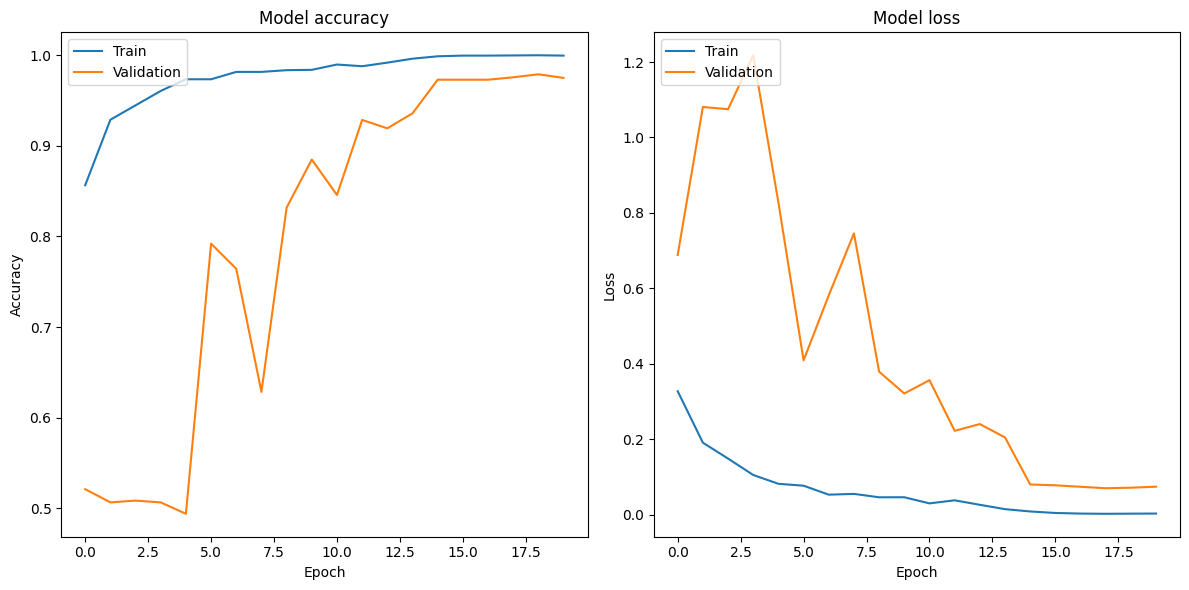

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
model.save('cnn.keras')

In [ ]:
def load_and_preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(path, color_mode="rgb", target_size=(128, 128))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.expand_dims(img, axis=0)
    img = img / 255.0
    return img

In [ ]:
image_path = '/content/mask image.jpg'
preprocessed_img = load_and_preprocess_image(image_path)
prediction = model.predict(preprocessed_img)
label = 'Without Mask' if prediction > 0.5 else 'With Mask'
print([label])

NameError: name 'load_and_preprocess_image' is not defined

In [ ]:
model.save('cnn.keras')

In [ ]:
pip install gradio


In [33]:
import gradio as gr
from gradio.themes import Soft,Default
import tensorflow as tf
import numpy as np
import tensorflow.keras
import keras.models

In [34]:
model = keras.models.load_model('cnn.keras')

In [35]:
from PIL import Image

In [36]:
def load_image(img:Image.Image):
  image_size = img.resize((128,128))
  image_to_array = np.array(image_size)/255.0
  image_to_array = np.expand_dims(image_to_array,axis=0)
  prediction = model.predict(image_to_array)[0][0]
  label = "❌ Without mask" if prediction > 0.5 else "✅ With mask"
  confidence = prediction if prediction > 0.5 else 1 - prediction
  return f"{label} (confidence : {confidence:.2f})"

In [37]:
gradio = gr.Interface(
    title='CNN Mask Classifier😷',
    description = 'Upload a image to know if a person is wearing a mask or not!',
    fn=load_image,
    inputs=gr.Image(type='pil', sources=['webcam', 'upload'], label='Upload an image or use webcam'),
    outputs = gr.Textbox(label= "prediction")
)
gradio.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e61de1ce693dff1b62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7863 <> https://e61de1ce693dff1b62.gradio.live
